## 設定と解法

In [1]:
import numpy as np
import matplotlib.pyplot as plt

k = 1.0
r = 1.0 / k          # 半径
a, b = 0.0, 0.0      # 円の中心（手計算: y(0)=-r, y'(0)=0 より原点）
x_end = 0.9 * r      # 爆発(x=r)手前まで

def rhs(x, Y):
    y, z = Y
    return np.array([z, k * (1 + z * z) ** 1.5])

def euler(n):
    h = x_end / n
    xs = np.linspace(0, x_end, n + 1)
    Y = np.array([-r, 0.0])
    out = [Y.copy()]
    for i in range(n):
        Y = Y + h * rhs(xs[i], Y)
        out.append(Y.copy())
    return xs, np.array(out)

def rk4(n):
    h = x_end / n
    xs = np.linspace(0, x_end, n + 1)
    Y = np.array([-r, 0.0])
    out = [Y.copy()]
    for i in range(n):
        x = xs[i]
        k1 = rhs(x, Y)
        k2 = rhs(x + h/2, Y + h/2 * k1)
        k3 = rhs(x + h/2, Y + h/2 * k2)
        k4 = rhs(x + h,   Y + h   * k3)
        Y = Y + h * (k1 + 2*k2 + 2*k3 + k4) / 6
        out.append(Y.copy())
    return xs, np.array(out)


## 円（解析解）との重ね描画

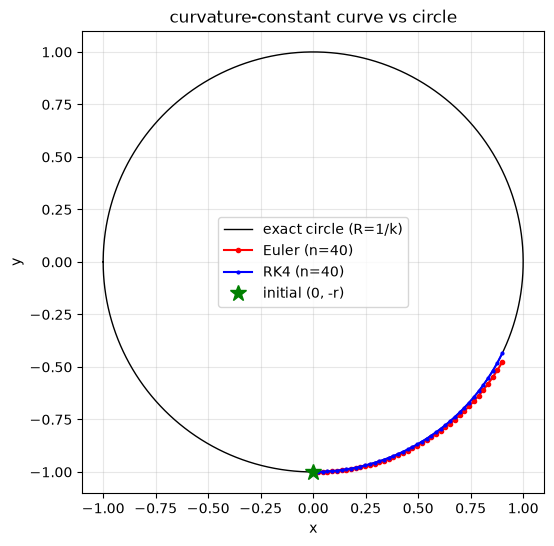

In [2]:
n = 40
xe, Ye = euler(n)
xr, Yr = rk4(n)
th = np.linspace(-np.pi, np.pi, 400)

plt.figure(figsize=(6, 6))
plt.plot(a + r*np.cos(th), b + r*np.sin(th), 'k-', lw=1, label='exact circle (R=1/k)')
plt.plot(xe, Ye[:, 0], 'ro-', ms=3, label=f'Euler (n={n})')
plt.plot(xr, Yr[:, 0], 'b.-', ms=4, label=f'RK4 (n={n})')
plt.plot(0, -r, 'g*', ms=12, label='initial (0, -r)')
plt.gca().set_aspect('equal'); plt.legend(); plt.grid(alpha=0.3)
plt.xlabel('x'); plt.ylabel('y'); plt.title('curvature-constant curve vs circle')
plt.show()


## 誤差 $\epsilon(x)$ の分布（n=40）

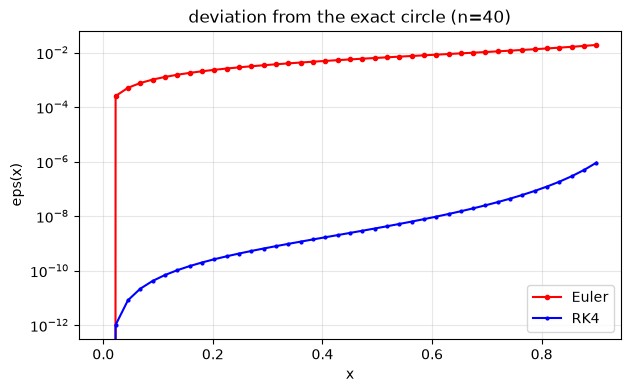

In [3]:
def eps(xs, Y):
    return np.abs(np.sqrt((xs - a)**2 + (Y[:, 0] - b)**2) - r)

plt.figure(figsize=(7, 4))
plt.plot(xe, eps(xe, Ye), 'ro-', ms=3, label='Euler')
plt.plot(xr, eps(xr, Yr), 'b.-', ms=4, label='RK4')
plt.yscale('log'); plt.xlabel('x'); plt.ylabel('eps(x)')
plt.legend(); plt.grid(alpha=0.3); plt.title('deviation from the exact circle (n=40)')
plt.show()


## 収束次数の比較（分割数 n を変えて最大誤差を測る）

    n           h     max eps (Euler)       max eps (RK4)
   10     0.09000           6.125e-02           1.284e-04
   20     0.04500           3.473e-02           1.207e-05
   40     0.02250           1.895e-02           9.133e-07
   80     0.01125           1.002e-02           6.208e-08
  160     0.00562           5.171e-03           4.028e-09
  320     0.00281           2.631e-03           2.562e-10
  640     0.00141           1.328e-03           1.615e-11

収束次数（log-log の傾き）: Euler = 0.93,  RK4 = 3.84


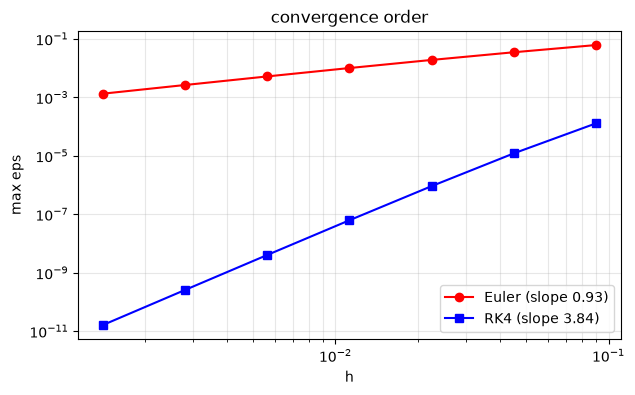

In [4]:
ns = [10, 20, 40, 80, 160, 320, 640]
err_e, err_r = [], []
for n in ns:
    xe, Ye = euler(n); xr, Yr = rk4(n)
    err_e.append(eps(xe, Ye).max())
    err_r.append(eps(xr, Yr).max())

hs = x_end / np.array(ns)
oe = np.polyfit(np.log(hs), np.log(err_e), 1)[0]
orr = np.polyfit(np.log(hs), np.log(err_r), 1)[0]

print(f"{'n':>5}{'h':>12}{'max eps (Euler)':>20}{'max eps (RK4)':>20}")
for i, n in enumerate(ns):
    print(f"{n:>5}{hs[i]:>12.5f}{err_e[i]:>20.3e}{err_r[i]:>20.3e}")
print(f"\n収束次数（log-log の傾き）: Euler = {oe:.2f},  RK4 = {orr:.2f}")

plt.figure(figsize=(7, 4))
plt.loglog(hs, err_e, 'ro-', label=f'Euler (slope {oe:.2f})')
plt.loglog(hs, err_r, 'bs-', label=f'RK4 (slope {orr:.2f})')
plt.xlabel('h'); plt.ylabel('max eps'); plt.legend(); plt.grid(alpha=0.3, which='both')
plt.title('convergence order'); plt.show()


## 比較の方法と結論

- **比較方法**: 数値解 $\tilde y$ と厳密な円（中心 $(0,0)$, 半径 $r=1/k$）との乖離 $\epsilon(x)$ の最大値を、分割数 $n$（刻み幅 $h=x_{\rm end}/n$）を変えて測り、log–log の傾きで収束次数を推定した。
- **結論**: Euler 法は理論通り 1 次収束（傾き ≈ 1、$h$ を半分で誤差 1/2）、RK4 は 4 次収束（傾き ≈ 4、$h$ を半分で誤差 1/16）。同じ分割数でも RK4 は Euler より桁違いに高精度。
- 爆発点 $x=r$ に近づくほど $y'=z$ が大きくなり両者とも誤差が増大するため、手前で打ち切っている。
